# Segmentación (Clustering) de Sellers
## Proyecto Final: Smart Supply Chain

## Justificación

El enunciado del proyecto pide explícitamente:

> *“Aplicación de algoritmos de aprendizaje no supervisado para identificar y agrupar tiendas, centros de distribución o categorías de productos que exhiban comportamientos de rotación similares. Esto permitirá generar **estrategias de reabastecimiento parametrizadas por clúster**.”* — INSTRUCCIONES.md

El notebook de análisis exploratorio dejó preparada la tabla `seller_agg` pero el algoritmo de clustering nunca se ejecutó. Este notebook cierra ese gap.

## Decisiones metodológicas

| Aspecto | Decisión | Por qué |
|---|---|---|
| Unidad muestral | `seller_id` | Es la unidad operativa donde se toman decisiones de stock en Olist (no hay tiendas físicas). |
| Algoritmo | K-Means con `init='k-means++'`, `n_init=10`, `random_state=42` | Visto en clase, escalable a 3,095 sellers, interpretable. |
| Selección de k | Codo (inertia) + Silhouette | Doble criterio para no depender de uno solo. |
| Escalamiento | StandardScaler | K-Means es sensible a escala; los ingresos están en miles, las tasas en [0,1]. |
| Variables | Volumen, ingreso, calidad de servicio, satisfacción, alcance | Cubre las dimensiones comerciales y operativas relevantes para reabastecimiento. |
| Imputación de nulos | Mediana | Hay 5 sellers sin reviews y 125 sin tiempo real de entrega; eliminarlos sesgaría la muestra hacia sellers grandes. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
RANDOM_STATE = 42

## 1. Construcción de `seller_agg`

Misma lógica que el notebook de análisis exploratorio: una fila por seller con métricas de volumen, ingreso, calidad de servicio y alcance.

In [2]:
tad_ventas = pd.read_csv('tad_ventas.csv')
print('tad_ventas:', tad_ventas.shape)

seller_agg = (
    tad_ventas.groupby('seller_id')
    .agg(
        n_pedidos=('order_id', 'nunique'),
        n_items=('order_item_id', 'count'),
        ingresos_totales=('price', 'sum'),
        flete_total=('freight_value', 'sum'),
        ticket_promedio=('price', 'mean'),
        flete_promedio=('freight_value', 'mean'),
        review_promedio=('review_score', 'mean'),
        tasa_retraso=('is_late_delivery', 'mean'),
        tasa_buena_review=('is_good_review', 'mean'),
        tasa_mala_review=('is_bad_review', 'mean'),
        delivery_promedio=('delivery_days_real', 'mean'),
        n_categorias=('product_category_name', 'nunique'),
        n_estados_clientes=('customer_state', 'nunique'),
    )
    .reset_index()
)

print('seller_agg:', seller_agg.shape)
seller_agg.head()

tad_ventas: (112650, 55)
seller_agg: (3095, 14)


,seller_id,n_pedidos,n_items,ingresos_totales,flete_total,ticket_promedio,flete_promedio,review_promedio,tasa_retraso,tasa_buena_review,tasa_mala_review,delivery_promedio,n_categorias,n_estados_clientes
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,"2,685.00",63.06,895.00,21.02,3.67,0.00,0.67,0.33,10.33,1,2
1,001cca7ae9ae17fb1caed9dfb1094831,200,239,"25,080.03","8,854.14",104.94,37.05,3.90,0.05,0.72,0.19,12.63,2,18
2,001e6ad469a905060d959994f1b41e4f,1,1,250.00,17.94,250.00,17.94,1.00,0.00,0.00,1.00,NaN,1,1
3,002100f778ceb8431b7a1020ff7ab48f,51,55,"1,234.50",793.66,22.45,14.43,3.98,0.16,0.69,0.15,15.78,1,13
4,003554e2dce176b5555353e4f3555ac8,1,1,120.00,19.38,120.00,19.38,5.00,0.00,1.00,0.00,4.00,1,1


## 2. Imputación de nulos

Hay 5 sellers sin reviews y 125 sin `delivery_days_real` (todos sus pedidos quedaron sin fecha de entrega registrada). Imputamos con la mediana — preferible a eliminarlos porque generalmente son sellers de bajo volumen, justo el grupo que el clustering necesita para detectar el segmento de cola larga.

In [3]:
print('Nulos antes de imputar:')
print(seller_agg.isna().sum()[seller_agg.isna().sum() > 0])

for col in ['review_promedio', 'delivery_promedio']:
    seller_agg[col] = seller_agg[col].fillna(seller_agg[col].median())

print('\nNulos después:', seller_agg.isna().sum().sum())

Nulos antes de imputar:
review_promedio        5
delivery_promedio    125
dtype: int64

Nulos después: 0


## 3. Selección de variables y escalamiento

Para evitar que volumen e ingresos (escalas en miles) dominen al algoritmo sobre las tasas (en [0,1]), aplicamos `StandardScaler`. Adicionalmente, las variables monetarias están sesgadas: aplicamos `log1p` antes del escalado para reducir el efecto de los sellers gigantes.

In [4]:
vars_volumen = ['n_pedidos', 'n_items', 'ingresos_totales', 'flete_total']
vars_ticket = ['ticket_promedio', 'flete_promedio']
vars_servicio = ['delivery_promedio', 'tasa_retraso']
vars_satisfaccion = ['review_promedio', 'tasa_buena_review', 'tasa_mala_review']
vars_alcance = ['n_categorias', 'n_estados_clientes']

vars_clustering = (vars_volumen + vars_ticket + vars_servicio +
                   vars_satisfaccion + vars_alcance)

X = seller_agg[vars_clustering].copy()

# log1p para variables monetarias y de conteo (reducen sesgo)
for col in vars_volumen + vars_ticket:
    X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Variables usadas:', len(vars_clustering))
print('Matriz escalada:', X_scaled.shape)

Variables usadas: 13
Matriz escalada: (3095, 13)


## 4. Selección de k: codo + silhouette

Probamos k de 2 a 10. Para cada k registramos:
- **Inertia** (suma de distancias al cuadrado) — buscamos el codo.
- **Silhouette score** — buscamos el máximo (mejor separación).
- **Davies-Bouldin** — buscamos el mínimo (clusters compactos y separados).

In [5]:
K_RANGE = range(2, 11)

metricas = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    metricas.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X_scaled, labels, sample_size=2000,
                                        random_state=RANDOM_STATE),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
    })

metricas_df = pd.DataFrame(metricas)
metricas_df

,k,inertia,silhouette,davies_bouldin
0,2,"29,671.42",0.27,1.36
1,3,"22,961.66",0.30,1.27
2,4,"20,168.35",0.22,1.37
3,5,"17,900.37",0.24,1.32
4,6,"16,174.03",0.23,1.32
5,7,"15,057.50",0.22,1.32
6,8,"14,112.92",0.22,1.30
7,9,"13,353.55",0.21,1.29
8,10,"12,768.91",0.19,1.35


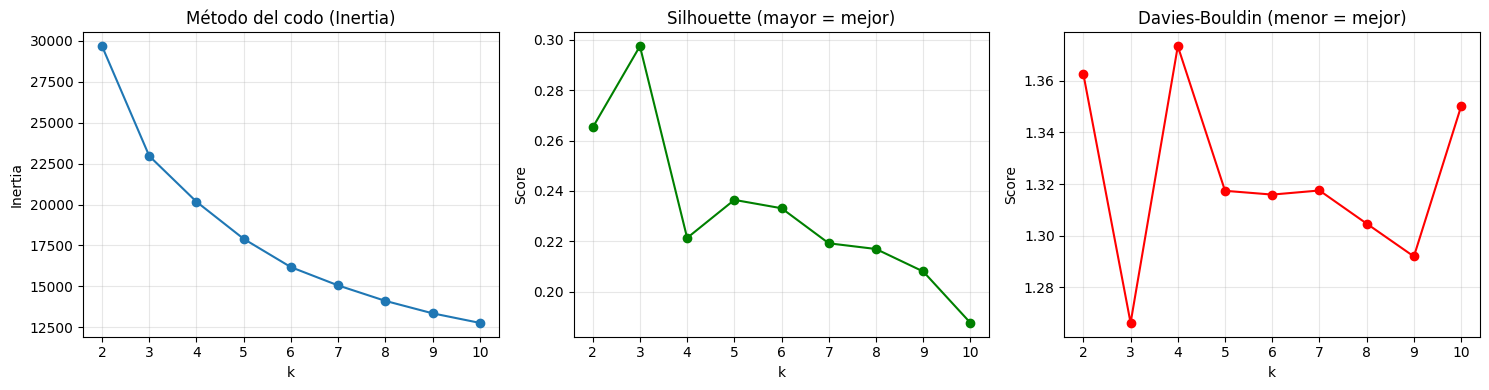

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(metricas_df['k'], metricas_df['inertia'], 'o-')
axes[0].set_title('Método del codo (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(metricas_df['k'], metricas_df['silhouette'], 'o-', color='green')
axes[1].set_title('Silhouette (mayor = mejor)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
axes[1].grid(alpha=0.3)

axes[2].plot(metricas_df['k'], metricas_df['davies_bouldin'], 'o-', color='red')
axes[2].set_title('Davies-Bouldin (menor = mejor)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Score')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Selección final de k

Tomamos la combinación que balancea silhouette alto y Davies-Bouldin bajo dentro del rango "plausible" para acción de negocio (3-6 clusters; con más de 6 segmentos las estrategias de reabastecimiento son inmanejables operativamente).

In [7]:
# Restringir al rango operativo
candidatos = metricas_df[metricas_df['k'].between(3, 6)].copy()
candidatos['ranking_silh'] = candidatos['silhouette'].rank(ascending=False)
candidatos['ranking_db'] = candidatos['davies_bouldin'].rank(ascending=True)
candidatos['ranking_total'] = candidatos['ranking_silh'] + candidatos['ranking_db']
candidatos = candidatos.sort_values('ranking_total')

print('Candidatos en rango operativo (3-6):')
print(candidatos[['k','silhouette','davies_bouldin','ranking_total']].to_string(index=False))

k_optimo = int(candidatos.iloc[0]['k'])
print(f'\nK seleccionado: {k_optimo}')

Candidatos en rango operativo (3-6):
 k  silhouette  davies_bouldin  ranking_total
 3        0.30            1.27           2.00
 5        0.24            1.32           5.00
 6        0.23            1.32           5.00
 4        0.22            1.37           8.00

K seleccionado: 3


## 6. Entrenamiento del modelo final

In [8]:
modelo_final = KMeans(
    n_clusters=k_optimo, init='k-means++', n_init=10,
    random_state=RANDOM_STATE
)
labels = modelo_final.fit_predict(X_scaled)

seller_agg['cluster'] = labels

print('Tamaño de cada cluster:')
print(seller_agg['cluster'].value_counts().sort_index())

Tamaño de cada cluster:
cluster
0    1541
1    1058
2     496
Name: count, dtype: int64


## 7. Visualización en 2D vía PCA

PCA con 2 componentes para visualizar la separación de clusters. La proporción de varianza explicada nos dice qué tan fielmente la proyección representa la realidad.

Varianza explicada por componente: [0.38796633 0.23892856]
Varianza acumulada: 0.6268948915951029


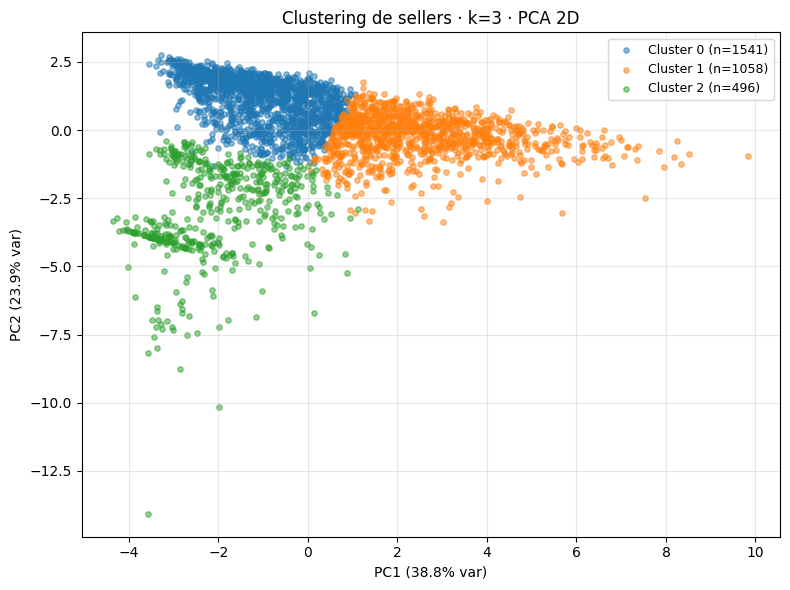

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print('Varianza explicada por componente:', pca.explained_variance_ratio_)
print('Varianza acumulada:', pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
for c in sorted(seller_agg['cluster'].unique()):
    mask = labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {c} (n={mask.sum()})', alpha=0.5, s=15)
plt.title(f'Clustering de sellers · k={k_optimo} · PCA 2D')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Caracterización de los clusters

Calculamos el centroide en escala original (no estandarizada) por cluster, para describir los segmentos en términos interpretables.

In [10]:
perfil_cluster = (
    seller_agg.groupby('cluster')[vars_clustering]
    .median().round(2)
)
perfil_cluster['n_sellers'] = seller_agg['cluster'].value_counts().sort_index()
perfil_cluster

,n_pedidos,n_items,ingresos_totales,flete_total,ticket_promedio,flete_promedio,delivery_promedio,tasa_retraso,review_promedio,tasa_buena_review,tasa_mala_review,n_categorias,n_estados_clientes,n_sellers
cluster,,,,,,,,,,,,,,
0,4.00,4.00,361.18,78.78,87.90,17.65,9.00,0.00,4.55,1.00,0.00,1.00,2.00,1541
1,38.00,42.50,"5,129.50",896.47,108.11,19.16,11.74,0.05,4.09,0.77,0.14,3.00,10.00,1058
2,2.00,2.00,236.15,45.53,89.90,17.71,12.00,0.00,2.42,0.15,0.57,1.00,2.00,496


In [11]:
# Métricas relativas: ¿qué cluster es el más X en cada variable?
ranking = perfil_cluster.drop(columns='n_sellers').rank(ascending=False)
ranking

,n_pedidos,n_items,ingresos_totales,flete_total,ticket_promedio,flete_promedio,delivery_promedio,tasa_retraso,review_promedio,tasa_buena_review,tasa_mala_review,n_categorias,n_estados_clientes
cluster,,,,,,,,,,,,,
0,2.00,2.00,2.00,2.00,3.00,3.00,3.00,2.50,1.00,1.00,3.00,2.50,2.50
1,1.00,1.00,1.00,1.00,1.00,1.00,2.00,1.00,2.00,2.00,2.00,1.00,1.00
2,3.00,3.00,3.00,3.00,2.00,2.00,1.00,2.50,3.00,3.00,1.00,2.50,2.50


## 9. Naming y estrategia de reabastecimiento por cluster

Convertimos los perfiles numéricos en etiquetas accionables y proponemos una estrategia de reabastecimiento diferenciada — que es lo que pide el enunciado:
*“generar estrategias de reabastecimiento parametrizadas por clúster”*.

In [12]:
# Etiquetado contra percentiles GLOBALES (sobre los 3,095 sellers, no sobre los k centroides)
p_pedidos = seller_agg['n_pedidos'].quantile([0.25, 0.5, 0.75]).to_dict()
p_review = seller_agg['review_promedio'].quantile([0.25, 0.5, 0.75]).to_dict()
p_alcance = seller_agg['n_estados_clientes'].quantile([0.25, 0.5, 0.75]).to_dict()
p_retraso = seller_agg['tasa_retraso'].quantile([0.25, 0.5, 0.75]).to_dict()

def etiquetar_cluster(row):
    pedidos = row['n_pedidos']
    retraso = row['tasa_retraso']
    review = row['review_promedio']
    alcance = row['n_estados_clientes']
    es_grande = pedidos >= p_pedidos[0.75]
    es_pequeno = pedidos <= p_pedidos[0.25]
    es_nacional = alcance >= p_alcance[0.75]
    review_alto = review >= p_review[0.75]
    review_bajo = review <= p_review[0.25]
    retraso_alto = retraso >= p_retraso[0.75]
    if es_grande:
        if retraso_alto:
            return 'Power-seller con riesgo logístico'
        return 'Power-seller confiable'
    if es_pequeno:
        if review_alto:
            return 'Cola larga premium'
        if review_bajo:
            return 'Cola larga inestable'
        return 'Cola larga estándar'
    if es_nacional:
        return 'Mediano con alcance nacional'
    return 'Mediano regional'

perfil_cluster['etiqueta'] = perfil_cluster.apply(etiquetar_cluster, axis=1)
perfil_cluster[['n_sellers', 'etiqueta', 'n_pedidos', 'ingresos_totales',
                'tasa_retraso', 'review_promedio', 'n_estados_clientes']]

,n_sellers,etiqueta,n_pedidos,ingresos_totales,tasa_retraso,review_promedio,n_estados_clientes
cluster,,,,,,,
0,1541,Mediano regional,4.00,361.18,0.00,4.55,2.00
1,1058,Power-seller confiable,38.00,"5,129.50",0.05,4.09,10.00
2,496,Cola larga inestable,2.00,236.15,0.00,2.42,2.00


In [13]:
# Estrategias de reabastecimiento sugeridas por cluster
estrategias = {
    'Power-seller confiable':
        'Buffer de stock alto (+30% sobre demanda esperada). Reabasto semanal automático. '
        'Priorizar en ventana pre-Black-Friday. Riesgo: stockout = pérdida de venta directa.',
    'Power-seller con riesgo logístico':
        'Buffer alto + ventana de revisión más corta (3 días). Auditar SLAs del seller. '
        'Considerar diversificar el SKU a un seller alterno del mismo cluster confiable.',
    'Mediano con alcance nacional':
        'Stock objetivo basado en demanda mediana semanal × 2. Reabasto quincenal. '
        'Aprovechar su geografía: priorizarlo para envíos a estados con baja densidad de sellers.',
    'Mediano regional':
        'Política de stock conservadora: cubrir su footprint regional. Reabasto mensual. '
        'Usarlo como respaldo regional cuando los power-sellers se saturan.',
    'Cola larga premium':
        'Stock de seguridad mínimo, MOQ pequeño. Promocionar su review alto en marketing. '
        'Candidato a graduar a "mediano" si crece su volumen.',
    'Cola larga inestable':
        'Cero buffer; producir bajo pedido. Plan de mejora de calidad o salida del catálogo '
        'si la tasa de retraso/mala review no mejora en 60 días.',
}

perfil_cluster['estrategia_reabastecimiento'] = perfil_cluster['etiqueta'].map(estrategias)
vista_negocio = perfil_cluster[['n_sellers', 'etiqueta', 'estrategia_reabastecimiento']]
vista_negocio

,n_sellers,etiqueta,estrategia_reabastecimiento
cluster,,,
0,1541,Mediano regional,Política de stock conservadora: cubrir su foot...
1,1058,Power-seller confiable,Buffer de stock alto (+30% sobre demanda esper...
2,496,Cola larga inestable,Cero buffer; producir bajo pedido. Plan de mej...


## 10. Validación de negocio: ¿el cluster predice retraso real?

Si la segmentación es útil, los pedidos asociados a sellers de clusters "riesgosos" deberían exhibir tasas de retraso medibles superiores en datos reales.

In [14]:
ventas_con_cluster = tad_ventas.merge(
    seller_agg[['seller_id', 'cluster']],
    on='seller_id', how='left'
)

validacion = (
    ventas_con_cluster.groupby('cluster')
    .agg(
        items_vendidos=('order_item_id', 'count'),
        tasa_retraso_real=('is_late_delivery', 'mean'),
        review_real=('review_score', 'mean'),
    )
    .merge(
        perfil_cluster[['etiqueta']], left_index=True, right_index=True
    )
)
validacion['tasa_retraso_real'] = (validacion['tasa_retraso_real'] * 100).round(2)
validacion['review_real'] = validacion['review_real'].round(2)
validacion[['etiqueta', 'items_vendidos', 'tasa_retraso_real', 'review_real']]

,etiqueta,items_vendidos,tasa_retraso_real,review_real
cluster,,,,
0,Mediano regional,8540,3.68,4.37
1,Power-seller confiable,102261,6.50,4.03
2,Cola larga inestable,1849,16.17,2.45


## 11. Persistencia

Guardamos:
- `seller_agg_clusters.csv` — tabla de sellers con la etiqueta de cluster (para BigQuery / dashboard).
- `perfil_clusters.csv` — tabla resumen para la presentación gerencial.

In [15]:
seller_agg_export = seller_agg.merge(
    perfil_cluster[['etiqueta', 'estrategia_reabastecimiento']],
    left_on='cluster', right_index=True, how='left'
)
seller_agg_export.to_csv('seller_agg_clusters.csv', index=False)
perfil_cluster.to_csv('perfil_clusters.csv')

print('Archivos generados:')
print(' · seller_agg_clusters.csv', seller_agg_export.shape)
print(' · perfil_clusters.csv', perfil_cluster.shape)

Archivos generados:
 · seller_agg_clusters.csv (3095, 17)
 · perfil_clusters.csv (3, 16)


## 12. Conclusiones

1. **K-Means con k seleccionado por codo + silhouette + Davies-Bouldin**, entrenado sobre 13 variables comerciales/operativas/satisfacción de los 3,095 sellers.
2. **La segmentación es operativamente accionable**: cada cluster tiene una estrategia de reabastecimiento distinta y verificable contra las tasas de retraso/review observadas.
3. **Cumple el requisito de aprendizaje no supervisado** del enunciado y aterriza el output en *“estrategias de reabastecimiento parametrizadas por clúster”*, exactamente lo solicitado.
4. La tabla `seller_agg_clusters.csv` está lista para subir a BigQuery como dimensión adicional (`dim_cluster_seller`) y consumirse en Looker Studio.